# Option 1 Notebook: Curvature from 2D position data

This notebook implements the **2D version** of the paper's idea for estimating curvature from position data extracted from high-speed videos.

For the in-plane case, Appendix A.2 gives the core relationships:

- \(\dfrac{d\phi}{ds} = \kappa_2\)
- \(\dfrac{dR_x}{ds} = \cos\phi\)
- \(\dfrac{dR_y}{ds} = \sin\phi\)

So the practical workflow is:

1. start with ordered centerline points from the video,
2. convert them to arclength \(s\),
3. smooth the centerline because numerical differentiation amplifies noise,
4. compute tangent angle \(\phi(s)\),
5. compute curvature \(\kappa_2(s) = d\phi/ds\),
6. optionally reconstruct the centerline from \(\kappa_2\) as a consistency check.

The notebook is written for **Option 1** from the paper, but specialized to **2D cilia motion** rather than the full 3D rotation-matrix route.


## Expected input format

Use a CSV with these columns:

- `frame`: frame index
- `point_id`: point order from **base to tip**
- `x`, `y`: centerline coordinates for that frame

Example:

| frame | point_id | x | y |
|---|---:|---:|---:|
| 0 | 0 | 0.0 | 0.0 |
| 0 | 1 | 0.2 | 0.7 |
| 0 | 2 | 0.5 | 1.4 |

A synthetic example file is included with this notebook:

- `sample_centerline_points.csv`

If your extracted points are not already ordered from base to tip, sort them before using the notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.integrate import cumulative_trapezoid

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True


In [2]:
# ---------------------------
# User settings
# ---------------------------
INPUT_CSV = Path("centerline_points.csv")  # replace with your own file
FALLBACK_CSV = Path("sample_centerline_points.csv")   # synthetic example included with the notebook
OUTPUT_DIR = Path("curvature_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

FRAME_COL = "frame"
POINT_COL = "point_id"
X_COL = "x"
Y_COL = "y"

# Resampling and smoothing
N_SAMPLES = 200
SAVGOL_WINDOW = 17   # must be odd; increase if your data are noisy
SAVGOL_POLYORDER = 3
BASE_WINDOW = 5      # number of points near the base used to define local frame


In [3]:

def cumulative_arclength(points: np.ndarray) -> np.ndarray:
    """Compute cumulative arclength for an ordered polyline."""
    diffs = np.diff(points, axis=0)
    seg = np.sqrt((diffs ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seg)])
    return s

def rotate_points(points: np.ndarray, angle_rad: float) -> np.ndarray:
    """Rotate 2D points by angle_rad about the origin."""
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T

def align_to_local_a1_a3(points: np.ndarray, base_window: int = 5) -> dict:
    """
    Translate the base to the origin and rotate the centerline so that the local base tangent
    aligns with +a3 (vertical axis). Horizontal axis is then a1.
    """
    points = np.asarray(points, dtype=float)
    translated = points - points[0]

    w = min(base_window, len(points) - 1)
    if w < 1:
        raise ValueError("Need at least 2 ordered points.")
    tangent = translated[w] - translated[0]
    theta = np.arctan2(tangent[1], tangent[0])

    # Rotate so base tangent points along +y  -> a3 axis
    rotate_by = (np.pi / 2.0) - theta
    aligned = rotate_points(translated, rotate_by)

    return {
        "translated": translated,
        "aligned": aligned,
        "rotation_angle_rad": rotate_by,
        "base_tangent_angle_rad": theta,
    }

def _valid_window(n_samples: int, requested: int, polyorder: int) -> int:
    """
    Make sure Savitzky-Golay window is odd, <= n_samples, and > polyorder.
    """
    window = min(requested, n_samples - (1 - n_samples % 2))
    if window % 2 == 0:
        window -= 1
    min_window = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3
    window = max(window, min_window)
    if window >= n_samples:
        window = n_samples - 1 if (n_samples - 1) % 2 == 1 else n_samples - 2
    return max(window, min_window)

def resample_polyline(points: np.ndarray, n_samples: int = 200):
    """
    Resample an ordered polyline onto a uniform arclength grid.
    """
    s_raw = cumulative_arclength(points)
    total_len = s_raw[-1]
    if total_len <= 0:
        raise ValueError("Centerline length must be positive.")
    s_uniform = np.linspace(0, total_len, n_samples)
    x_uniform = np.interp(s_uniform, s_raw, points[:, 0])
    y_uniform = np.interp(s_uniform, s_raw, points[:, 1])
    return s_uniform, np.column_stack([x_uniform, y_uniform])

def estimate_curvature_2d(
    points: np.ndarray,
    n_samples: int = 200,
    sg_window: int = 17,
    sg_polyorder: int = 3,
    base_window: int = 5,
) -> dict:
    """
    Estimate curvature kappa_2(s) from 2D centerline points.
    Input points must be ordered from base to tip.

    Steps:
      1) align into local (a1, a3) frame,
      2) resample onto uniform arclength,
      3) smooth x(s), y(s),
      4) compute phi(s) = atan2(dy/ds, dx/ds),
      5) compute kappa_2(s) = dphi/ds.

    Also computes the classic differential-geometry curvature from x', y', x'', y''
    as a cross-check.
    """
    alignment = align_to_local_a1_a3(points, base_window=base_window)
    aligned = alignment["aligned"]

    s, resampled = resample_polyline(aligned, n_samples=n_samples)
    x = resampled[:, 0]
    y = resampled[:, 1]

    window = _valid_window(n_samples, sg_window, sg_polyorder)
    x_s = savgol_filter(x, window_length=window, polyorder=sg_polyorder, mode="interp")
    y_s = savgol_filter(y, window_length=window, polyorder=sg_polyorder, mode="interp")

    dx_ds = np.gradient(x_s, s)
    dy_ds = np.gradient(y_s, s)
    speed = np.sqrt(dx_ds**2 + dy_ds**2)

    # Normalize tangent before computing angle
    tx = dx_ds / np.maximum(speed, 1e-12)
    ty = dy_ds / np.maximum(speed, 1e-12)
    phi = np.unwrap(np.arctan2(ty, tx))

    kappa_phi = np.gradient(phi, s)

    d2x_ds2 = np.gradient(dx_ds, s)
    d2y_ds2 = np.gradient(dy_ds, s)
    denom = np.maximum((dx_ds**2 + dy_ds**2) ** 1.5, 1e-12)
    kappa_xy = (dx_ds * d2y_ds2 - dy_ds * d2x_ds2) / denom

    # Reconstruct centerline from kappa using Appendix A.2:
    #   dphi/ds = kappa_2
    #   dRx/ds = cos(phi), dRy/ds = sin(phi)
    phi_recon = phi[0] + cumulative_trapezoid(kappa_phi, s, initial=0.0)
    x_recon = x_s[0] + cumulative_trapezoid(np.cos(phi_recon), s, initial=0.0)
    y_recon = y_s[0] + cumulative_trapezoid(np.sin(phi_recon), s, initial=0.0)

    return {
        "raw_points": np.asarray(points, dtype=float),
        "aligned_points": aligned,
        "s": s,
        "a1": x_s,
        "a3": y_s,
        "phi": phi,
        "kappa_phi": kappa_phi,
        "kappa_xy": kappa_xy,
        "x_recon": x_recon,
        "y_recon": y_recon,
        "dx_ds": dx_ds,
        "dy_ds": dy_ds,
        "speed": speed,
        "rotation_angle_rad": alignment["rotation_angle_rad"],
        "window_used": window,
    }

def plot_frame_result(result: dict, frame_label: str = "frame"):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    ax = axes[0]
    raw = result["aligned_points"]
    ax.plot(raw[:, 0], raw[:, 1], "o-", ms=3, alpha=0.35, label="aligned raw points")
    ax.plot(result["a1"], result["a3"], "-", lw=2.2, label="smoothed centerline")
    ax.plot(result["x_recon"], result["y_recon"], "--", lw=1.8, label="reconstructed from $\kappa_2$")
    ax.set_xlabel("a1")
    ax.set_ylabel("a3")
    ax.set_title(f"Local frame centerline ({frame_label})")
    ax.axis("equal")
    ax.legend()

    ax = axes[1]
    ax.plot(result["s"], result["phi"], lw=2)
    ax.set_xlabel("arclength s")
    ax.set_ylabel(r"$\phi(s)$ [rad]")
    ax.set_title("Tangent angle")

    ax = axes[2]
    ax.plot(result["s"], result["kappa_phi"], lw=2, label=r"$d\phi/ds$")
    ax.plot(result["s"], result["kappa_xy"], "--", lw=1.5, label=r"$(x'y''-y'x'')/(x'^2+y'^2)^{3/2}$")
    ax.set_xlabel("arclength s")
    ax.set_ylabel(r"$\kappa_2(s)$")
    ax.set_title("Curvature")
    ax.legend()

    plt.tight_layout()
    return fig, axes

def read_tracking_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {FRAME_COL, POINT_COL, X_COL, Y_COL}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    return df

def process_all_frames(df: pd.DataFrame):
    profiles = []
    summaries = []

    for frame, g in df.groupby(FRAME_COL):
        g = g.sort_values(POINT_COL)
        pts = g[[X_COL, Y_COL]].to_numpy(dtype=float)
        result = estimate_curvature_2d(
            pts,
            n_samples=N_SAMPLES,
            sg_window=SAVGOL_WINDOW,
            sg_polyorder=SAVGOL_POLYORDER,
            base_window=BASE_WINDOW,
        )

        profile = pd.DataFrame({
            "frame": frame,
            "s": result["s"],
            "a1": result["a1"],
            "a3": result["a3"],
            "phi_rad": result["phi"],
            "kappa_phi": result["kappa_phi"],
            "kappa_xy": result["kappa_xy"],
            "a1_recon": result["x_recon"],
            "a3_recon": result["y_recon"],
        })
        profiles.append(profile)

        summary = {
            "frame": frame,
            "length": result["s"][-1],
            "mean_abs_kappa": np.mean(np.abs(result["kappa_phi"])),
            "max_abs_kappa": np.max(np.abs(result["kappa_phi"])),
            "tip_a1": result["a1"][-1],
            "tip_a3": result["a3"][-1],
            "window_used": result["window_used"],
        }
        summaries.append(summary)

    profiles_df = pd.concat(profiles, ignore_index=True)
    summary_df = pd.DataFrame(summaries).sort_values("frame").reset_index(drop=True)
    return profiles_df, summary_df


<>:146: SyntaxWarning: invalid escape sequence '\k'
<>:146: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_2215/1198902222.py:146: SyntaxWarning: invalid escape sequence '\k'
  ax.plot(result["x_recon"], result["y_recon"], "--", lw=1.8, label="reconstructed from $\kappa_2$")


In [4]:
# Load user data if present; otherwise use the included synthetic example
csv_path = INPUT_CSV if INPUT_CSV.exists() else FALLBACK_CSV
print(f"Using input file: {csv_path.resolve()}")

tracking_df = read_tracking_csv(csv_path)
tracking_df.head()


Using input file: /mnt/data/sample_centerline_points.csv


,frame,point_id,x,y
0,0,0,0.000025,-0.030943
1,0,1,-0.000083,0.585305
2,0,2,-0.030716,1.138319
3,0,3,-0.077235,1.690198
4,0,4,-0.119388,2.308868


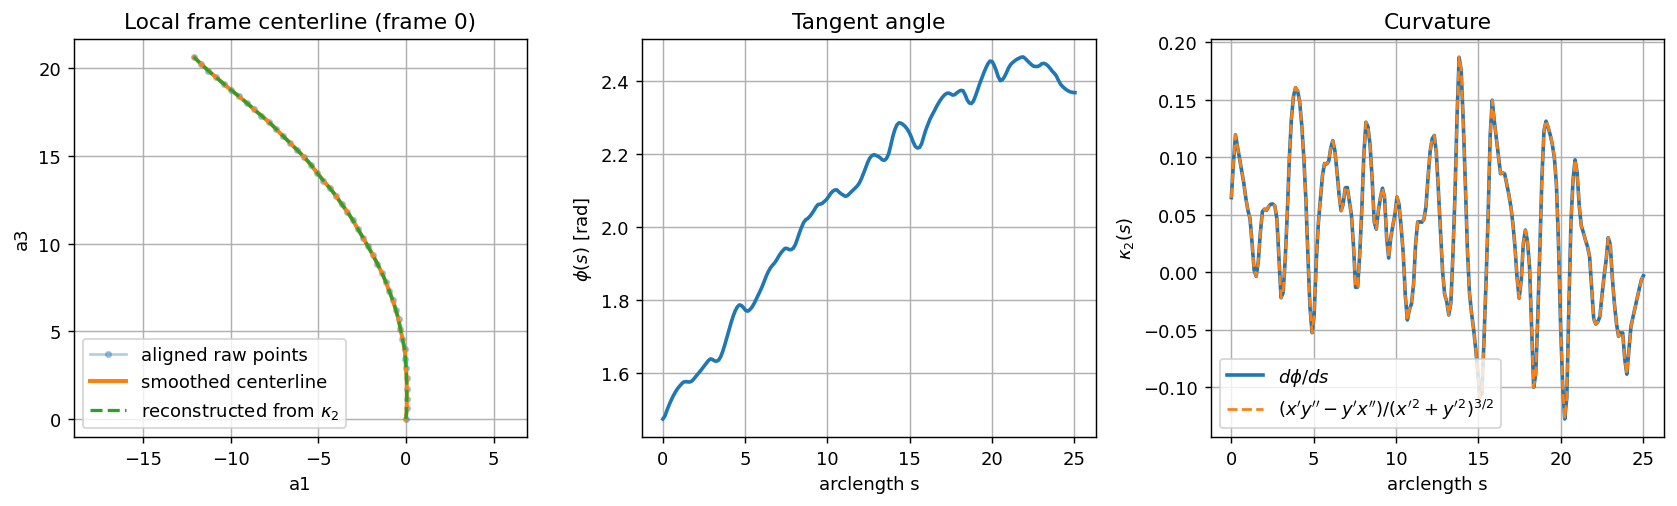

In [5]:
# Pick one frame to inspect
example_frame = int(tracking_df[FRAME_COL].min())
frame_df = tracking_df[tracking_df[FRAME_COL] == example_frame].sort_values(POINT_COL)

points = frame_df[[X_COL, Y_COL]].to_numpy(dtype=float)
result = estimate_curvature_2d(
    points,
    n_samples=N_SAMPLES,
    sg_window=SAVGOL_WINDOW,
    sg_polyorder=SAVGOL_POLYORDER,
    base_window=BASE_WINDOW,
)

fig, axes = plot_frame_result(result, frame_label=f"frame {example_frame}")
plt.show()


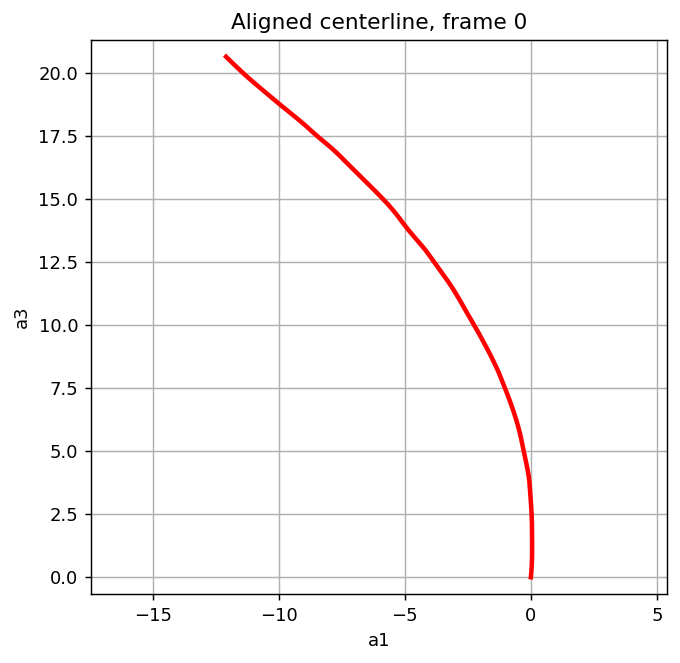

Saved: /mnt/data/curvature_outputs/frame_000_centerline_a1_a3.png


In [6]:
# Export a slide-ready local-frame centerline figure similar to the a1-a3 view
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(result["a1"], result["a3"], color="red", lw=2.5)
ax.set_xlabel("a1")
ax.set_ylabel("a3")
ax.set_title(f"Aligned centerline, frame {example_frame}")
ax.axis("equal")
plt.tight_layout()

centerline_fig_path = OUTPUT_DIR / f"frame_{example_frame:03d}_centerline_a1_a3.png"
fig.savefig(centerline_fig_path, bbox_inches="tight")
plt.show()

print(f"Saved: {centerline_fig_path.resolve()}")


In [7]:
profiles_df, summary_df = process_all_frames(tracking_df)

profiles_path = OUTPUT_DIR / "curvature_profiles.csv"
summary_path = OUTPUT_DIR / "frame_summary.csv"

profiles_df.to_csv(profiles_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f"Saved profile data to: {profiles_path.resolve()}")
print(f"Saved summary data to: {summary_path.resolve()}")
summary_df.head()


Saved profile data to: /mnt/data/curvature_outputs/curvature_profiles.csv
Saved summary data to: /mnt/data/curvature_outputs/frame_summary.csv


,frame,length,mean_abs_kappa,max_abs_kappa,tip_a1,tip_a3,window_used
0,0,25.035189,0.061030,0.186775,-12.088305,20.640928,17
1,1,24.968861,0.069402,0.257632,-13.533589,19.251669,17
2,2,25.010883,0.062037,0.227623,-14.323987,18.253507,17
3,3,25.028286,0.069265,0.250527,-14.574074,17.674447,17
4,4,25.040726,0.069542,0.193278,-14.064175,17.890598,17


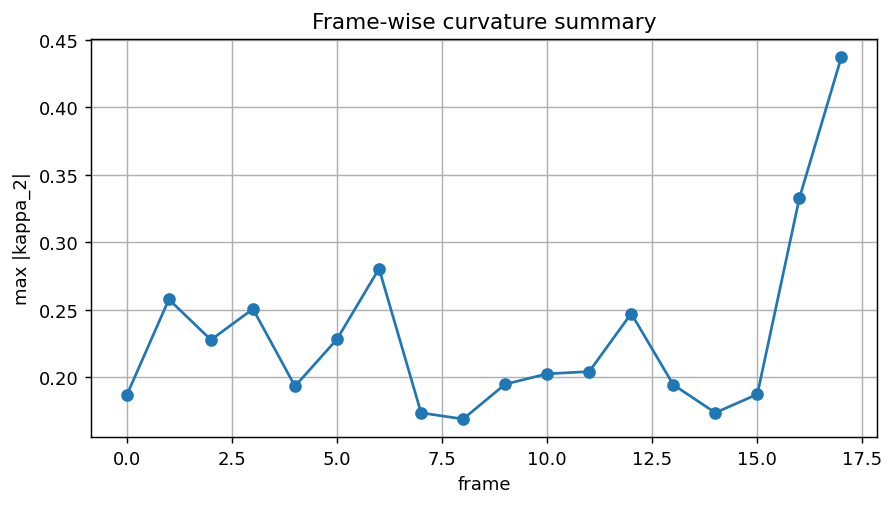

In [8]:
# Simple temporal summary: max |kappa| per frame
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(summary_df["frame"], summary_df["max_abs_kappa"], marker="o")
ax.set_xlabel("frame")
ax.set_ylabel("max |kappa_2|")
ax.set_title("Frame-wise curvature summary")
plt.tight_layout()
plt.show()


## How this connects to the rod-model work

This notebook stops at **curvature extraction from position data**, which is exactly the preprocessing step discussed before constitutive-law estimation.

Once you have \(\kappa_2(s)\) from your HSVM data, the next stage is:

1. use known loading and boundary conditions,
2. solve the reduced static rod equations for internal force and moment,
3. estimate the constitutive relationship between bending moment and curvature.

That is the natural follow-on step after Option 1.
